# STAT 4051 Group Project: Sparse PCA with *Breast Cancer Gene Expression Dataset*

In [3]:
! pip3.12 install kagglehub

  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.16-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.16-py3-none-any.whl (160 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [4]:
import kagglehub

path = kagglehub.dataset_download(
    "orvile/gene-expression-profiles-of-breast-cancer"
)
print(path)

100%|██████████| 107M/107M [00:04<00:00, 22.9MB/s] 

Extracting files...


/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1


In [5]:
import os
for root, dirs, files in os.walk(path):
    print(root, files)

/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1 []
/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1/GSE2034 []
/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1/GSE2034/GSE2034 ['GSE2034-Normal.txt', 'GSE2034-Tumor.txt']
/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1/GSE25066 []
/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1/GSE25066/GSE25066 ['GSE25066-Normal.txt', 'GSE25066-Tumor.txt']
/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1/Simulation-Data []
/Users/chenyixin/.cache/kagglehub/datasets/orvile/gene-expression-profiles-of-breast-cancer/versions/1/Simulation-Data/Simulation-Data ['Simulation-Data-Normal.txt', 'Simulation-Data-Tumor.txt', 'README']
/Users/c

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, SparsePCA
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

import seaborn as sns

We will compare the PCA and Sparse PCA below:

(590, 17815)
1695


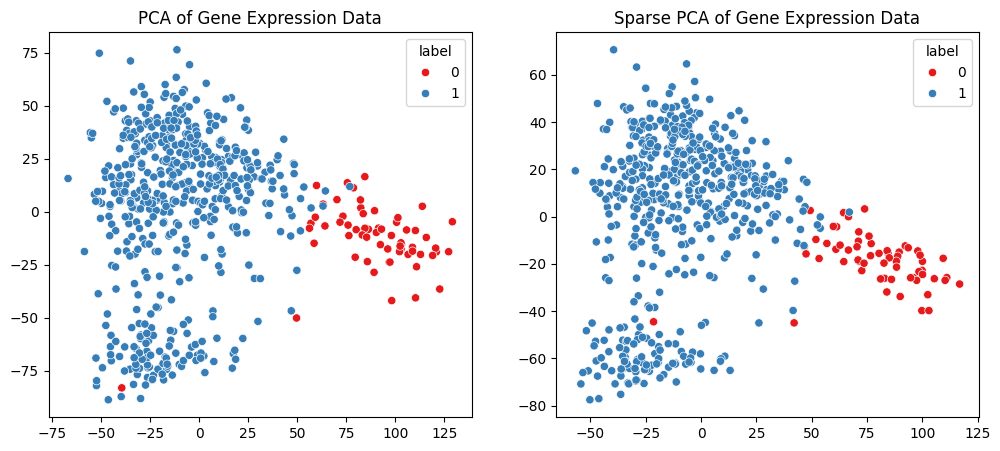

In [29]:

# load dataset
normal_file = os.path.join(path, "BC-TCGA", "BC-TCGA", "BC-TCGA-Normal.txt")
tumor_file = os.path.join(path, "BC-TCGA", "BC-TCGA", "BC-TCGA-Tumor.txt")
normal = pd.read_csv(normal_file, sep="\t")
tumor = pd.read_csv(tumor_file, sep="\t")

normal = normal.set_index("Hybridization REF")
tumor = tumor.set_index("Hybridization REF")

normal_T = normal.T
tumor_T = tumor.T

normal_T["label"] = 0
tumor_T["label"] = 1

# combine normal and tumor datasets
data = pd.concat([normal_T, tumor_T])
print(data.shape)
# print(data.head())
print(data.isna().sum().sum())
# separate features and labels
X = data.drop("label", axis=1)
y = data["label"]
# impute missing values
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X)
# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
# apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# apply Sparse PCA
sparse_pca = SparsePCA(n_components=2, alpha=5, random_state=42)
X_sparse_pca = sparse_pca.fit_transform(X_scaled)
# visualize PCA results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="Set1")
plt.title("PCA of Gene Expression Data")
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_sparse_pca[:, 0], y=X_sparse_pca[:, 1], hue=y, palette="Set1")
plt.title("Sparse PCA of Gene Expression Data")
plt.show()  


In [31]:
# PCA reconstruction
X_pca_recon = pca.inverse_transform(X_pca)
pca_error = np.mean((X_scaled - X_pca_recon) ** 2)

# Sparse PCA reconstruction
X_spca_recon = sparse_pca.inverse_transform(X_sparse_pca)
spca_error = np.mean((X_scaled - X_spca_recon) ** 2)

print("PCA reconstruction error:", pca_error)
print("Sparse PCA reconstruction error:", spca_error)

nonzero_pca = np.sum(pca.components_ != 0)
total_pca = pca.components_.size
print("PCA non-zero loadings:", nonzero_pca)
print("PCA sparsity ratio:", nonzero_pca / total_pca)

nonzero = np.sum(sparse_pca.components_ != 0)
total = sparse_pca.components_.size

print("Non-zero loadings:", nonzero)
print("Sparsity ratio:", nonzero / total)

PCA reconstruction error: 0.8374598306649593
Sparse PCA reconstruction error: 0.866317769401496
PCA non-zero loadings: 35628
PCA sparsity ratio: 1.0
Non-zero loadings: 16442
Sparsity ratio: 0.4614909621645896
